In [25]:
# Ejemplo de 
# Importar librerías 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
# Ruta del dataset
file_path = "C:/Git/vehicles_env/datasets/dataset_facebook_cosmetics_us.csv"

# Cargar dataframe
fb = pd.read_csv(file_path, sep=';')

In [27]:
# Crear matriz de correlación (solo numéricas)
num = fb.select_dtypes(include='number')
corr_m = num.corr(method = 'pearson')

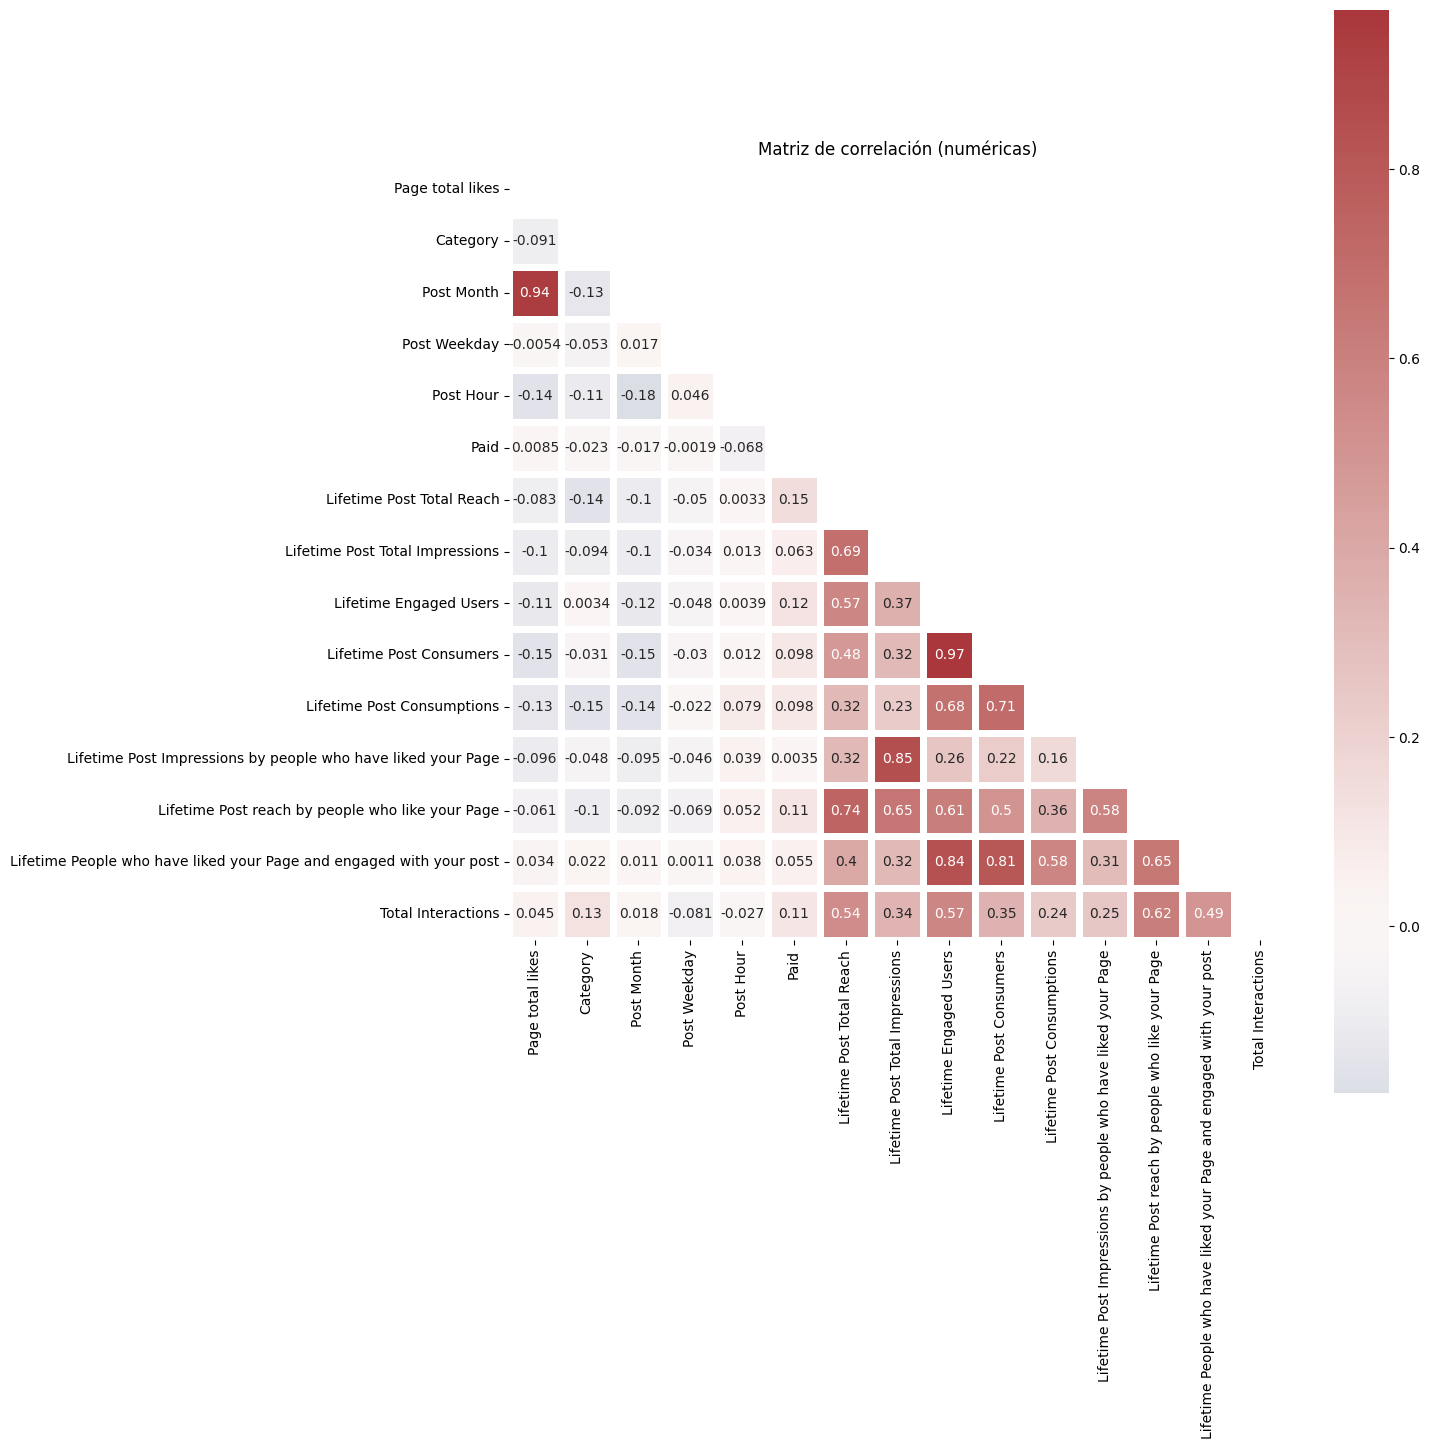

In [28]:
# Creación de mapa de calor
mask = np.triu(np.ones_like(corr_m, dtype=bool))
plt.figure(figsize=(15,15))
sns.heatmap(corr_m, mask=mask, cmap='vlag', center=0, linewidths=5, annot=True, square=True)
plt.title('Matriz de correlación (numéricas)')
plt.tight_layout()
plt.show()

Como podemos ver en la matriz de correlación, no hay características que muy probablemente nos den la respuesta correcta. Pero tenemos un par de características correlacionadas: 'Page total likes' y 'Post Month'. Pronto aprenderás a reducir el número de características en casos como estos.

In [29]:
# 3) correlación de la variable objetivo con las demás
# intenta detectar 'Total Interactions' con o sin guión bajo/espacios
target_candidates = [c for c in corr_m.columns if c.lower().replace(' ', '_') == 'total_interactions']
if target_candidates:
    target = target_candidates[0]
    corr_target = corr_m[target].drop(target).sort_values(key=lambda s: s.abs(), ascending=False)
    print('Correlación con la variable objetivo:\n', corr_target.head(15), '\n')

    # 4) ¿hay |corr| > 0.9?
    strong = corr_target[ corr_target.abs() > 0.9 ]
    if not strong.empty:
        print('⚠️ Hay variables con |correlación| > 0.9:\n', strong)
    else:
        print('No hay variables con |correlación| > 0.9.')
else:
    print("No encontré la columna 'Total Interactions' como numérica en el dataset.")

Correlación con la variable objetivo:
 Lifetime Post reach by people who like your Page                       0.617929
Lifetime Engaged Users                                                 0.572159
Lifetime Post Total Reach                                              0.538597
Lifetime People who have liked your Page and engaged with your post    0.492570
Lifetime Post Consumers                                                0.354502
Lifetime Post Total Impressions                                        0.343358
Lifetime Post Impressions by people who have liked your Page           0.250083
Lifetime Post Consumptions                                             0.238082
Category                                                               0.127307
Paid                                                                   0.107996
Post Weekday                                                          -0.081049
Page total likes                                                       0.045231
P

a) **Correlación de la meta (“Total Interactions”) con el resto**

* Las que más “caminan juntas” con las interacciones son las de **alcance y engagement** del post:

  * *Reach por fans* ≈ **0.62**
  * *Usuarios enganchados* ≈ **0.57**
  * *Alcance total del post* ≈ **0.54**
  * *Fans que vieron y se engancharon* ≈ **0.49**
  * También hay relación moderada con *consumers* e *impressions* (≈ **0.35–0.34**).
* Variables como **Paid** (\~0.11), **Category** (\~0.13), **Page total likes** (\~0.05) y las de **tiempo** (mes/día/hora, cercanas a 0) tienen **poca relación lineal** con las interacciones.
* Lectura simple: cuando el post **llega a más gente** (especialmente fans) y **hay más usuarios activos**, las interacciones suelen subir.

b) **¿Alguna con |correlación| > 0.9?**

* **No.** No hay ninguna característica con correlación absoluta mayor a **0.9** con la variable objetivo.

> Nota útil: muchas métricas de “reach/engagement” están **muy correlacionadas entre sí** (se parecen bastante). Si usas modelos lineales, esto puede dar inestabilidad; con árboles/bosques suele molestar menos. Y si tu objetivo es predecir **antes de publicar**, evita usar métricas que solo se conocen **después** (para no “hacer trampa”).
